# Notebook 04 — Rotations, Poses & Lie Groups

**Vision & 3D Mapping Workshop** | Block 2: 3-D Geometry

---

## Why This Matters

Every autonomous system — whether a drone stabilizing in wind, a robot arm grasping an object,
or a self-driving car fusing lidar and camera — must represent *where things are* in 3-D.
That means estimating how sensors **rotate** and **translate** relative to the world.  These
rigid-body transformations live in the *Special Euclidean group* $\text{SE}(3)$, and their
rotational part lives in the *Special Orthogonal group* $\text{SO}(3)$.  Neither is a vector
space: you cannot simply add two rotation matrices and get another rotation.  **Lie group
theory** provides the mathematical framework to do calculus on these curved spaces by mapping
them to vector spaces (Lie algebras) through the exponential and logarithm maps — which is
exactly what modern SLAM optimizers (g2o, GTSAM, Ceres) and state estimators do under the hood.

This notebook is the most mathematically rigorous in the workshop.  Every formula is
**derived**, not just stated.

### What You'll Learn

1. **$\text{SO}(3)$** — rotation matrices and their group properties
2. **Euler angles** — intuitive but dangerous (gimbal lock)
3. **Axis-angle & Rodrigues' formula** — full derivation from matrix exponential
4. **Quaternions** — Hamilton's algebra, SLERP interpolation, double cover
5. **$\text{SE}(3)$** — homogeneous transformations for rigid-body motion
6. **$\text{SO}(3)$ Lie theory** — exponential/logarithm maps, Jacobians
7. **$\text{SE}(3)$ Lie theory** — twists, the adjoint, frame transformations

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm

np.set_printoptions(precision=6, suppress=True)

import src.transforms as tf

---
## 1. Rotation Matrices and $\text{SO}(3)$

### Definition

The **Special Orthogonal group** in three dimensions is

$$
\text{SO}(3) = \{\, R \in \mathbb{R}^{3\times3} \;:\; R^\top R = I,\; \det(R) = +1 \,\}.
$$

### Proof that $\text{SO}(3)$ is a group

We must verify four axioms under matrix multiplication:

| Axiom | Proof |
|:---|:---|
| **Closure** | If $R_1, R_2 \in \text{SO}(3)$, then $(R_1 R_2)^\top (R_1 R_2) = R_2^\top R_1^\top R_1 R_2 = R_2^\top I R_2 = I$ and $\det(R_1 R_2)=\det(R_1)\det(R_2)=1$. |
| **Associativity** | Inherited from matrix multiplication. |
| **Identity** | $I \in \text{SO}(3)$ since $I^\top I = I$ and $\det(I) = 1$. |
| **Inverse** | $R^{-1} = R^\top$ and $(R^\top)^\top R^\top = R R^\top = I$, $\det(R^\top) = \det(R) = 1$.  $\square$ |

### Geometric interpretation

The **columns** of $R$ are the images of the standard basis vectors under the rotation:

$$
R = \begin{pmatrix} | & | & | \\ R\mathbf{e}_1 & R\mathbf{e}_2 & R\mathbf{e}_3 \\ | & | & | \end{pmatrix}
$$

They form a right-handed orthonormal frame — the rotated coordinate axes.

In [2]:
def is_rotation_matrix(R, tol=1e-6):
    """Check R^T R = I and det(R) = +1."""
    orth_err = np.linalg.norm(R.T @ R - np.eye(3), ord='fro')
    det_err = abs(np.linalg.det(R) - 1.0)
    return orth_err < tol and det_err < tol

R_good = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]], dtype=float)  # 90° about z
R_bad = np.array([[1, 1, 0], [0, 1, 0], [0, 0, 1]], dtype=float)    # shear, not SO(3)

print(f"R_good ∈ SO(3)? {is_rotation_matrix(R_good)}")
print(f"R_bad  ∈ SO(3)? {is_rotation_matrix(R_bad)}")
print(f"\nR_good columns (rotated basis):\n{R_good}")

R_good ∈ SO(3)? True
R_bad  ∈ SO(3)? False

R_good columns (rotated basis):
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]


---
## 2. Euler Angles

### ZYX intrinsic convention

We compose three elemental rotations about the body axes in order $z \to y \to x$:

$$
R = R_z(\psi)\, R_y(\theta)\, R_x(\phi)
$$

where the individual matrices are

$$
R_x(\phi) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{pmatrix}, \quad
R_y(\theta) = \begin{pmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{pmatrix}, \quad
R_z(\psi) = \begin{pmatrix} \cos\psi & -\sin\psi & 0 \\ \sin\psi & \cos\psi & 0 \\ 0 & 0 & 1 \end{pmatrix}.
$$

### Gimbal lock

When the pitch angle $\theta = \pi/2$, we have $\cos\theta = 0$ and $\sin\theta = 1$.  The
product collapses to

$$
R\big|_{\theta=\pi/2} = \begin{pmatrix}
  0 & \sin(\phi-\psi) & \cos(\phi-\psi) \\
  0 & \cos(\phi-\psi) & -\sin(\phi-\psi) \\
  -1 & 0 & 0
\end{pmatrix}.
$$

Only the *difference* $\phi - \psi$ appears — we have lost one degree of freedom.  Yaw and
roll are coupled and indistinguishable.  This is **gimbal lock**.

> **Warning**: All 12 Euler-angle conventions (XYZ, ZYX, ZXZ, …) suffer from gimbal lock at
> some configuration.  Always prefer quaternions or rotation matrices for computation.

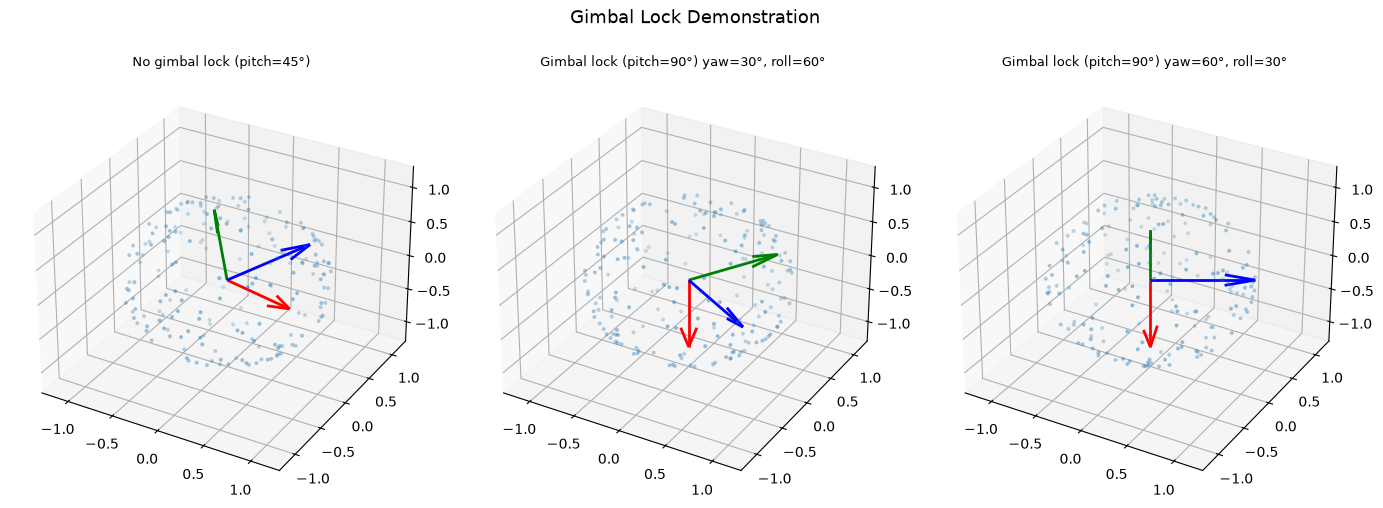

R(roll=60,pitch=90,yaw=30):
 [[ 0.        0.5       0.866025]
 [ 0.        0.866025 -0.5     ]
 [-1.        0.        0.      ]]
R(roll=50,pitch=90,yaw=20):
 [[ 0.        0.5       0.866025]
 [ 0.        0.866025 -0.5     ]
 [-1.        0.        0.      ]]

Difference Frobenius norm: 1.51e-17
Both have same (roll-yaw)=30°, so matrices are identical — 1 DOF lost!


In [3]:
# Demonstrate gimbal lock: vary yaw and roll with pitch = pi/2
sphere = np.random.randn(3, 200)
sphere = sphere / np.linalg.norm(sphere, axis=0)  # unit sphere

fig = plt.figure(figsize=(14, 5))

configs = [
    ("No gimbal lock (pitch=45°)", np.deg2rad(30), np.deg2rad(45), np.deg2rad(60)),
    ("Gimbal lock (pitch=90°) yaw=30°, roll=60°", np.deg2rad(60), np.deg2rad(90), np.deg2rad(30)),
    ("Gimbal lock (pitch=90°) yaw=60°, roll=30°", np.deg2rad(30), np.deg2rad(90), np.deg2rad(60)),
]

for i, (title, roll, pitch, yaw) in enumerate(configs):
    R = tf.rotation_matrix_from_euler(roll, pitch, yaw)
    pts = R @ sphere
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.scatter(pts[0], pts[1], pts[2], s=4, alpha=0.6)
    # Draw rotated axes
    for j, c in enumerate(['r', 'g', 'b']):
        ax.quiver(0, 0, 0, R[0,j], R[1,j], R[2,j], color=c, linewidth=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_zlim(-1.3, 1.3)

plt.suptitle("Gimbal Lock Demonstration", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Show the two gimbal-lock matrices are identical — yaw/roll are coupled
R_a = tf.rotation_matrix_from_euler(np.deg2rad(60), np.deg2rad(90), np.deg2rad(30))
R_b = tf.rotation_matrix_from_euler(np.deg2rad(50), np.deg2rad(90), np.deg2rad(20))
print("R(roll=60,pitch=90,yaw=30):\n", R_a.round(6))
print("R(roll=50,pitch=90,yaw=20):\n", R_b.round(6))
print(f"\nDifference Frobenius norm: {np.linalg.norm(R_a - R_b):.2e}")
print("Both have same (roll-yaw)=30°, so matrices are identical — 1 DOF lost!")

---
## 3. Axis-Angle & Rodrigues' Formula

### Setup

Any rotation can be described by a unit axis $\hat{\mathbf{k}}$ and angle $\theta$.  We encode
the axis as a **skew-symmetric matrix** (the "hat" operator):

$$
[\mathbf{k}]_\times = \begin{pmatrix} 0 & -k_3 & k_2 \\ k_3 & 0 & -k_1 \\ -k_2 & k_1 & 0 \end{pmatrix}
$$

so that $[\mathbf{k}]_\times \mathbf{v} = \mathbf{k} \times \mathbf{v}$ for any vector $\mathbf{v}$.

The rotation matrix is the **matrix exponential**:

$$
R = \exp\!\bigl(\theta\,[\hat{\mathbf{k}}]_\times\bigr).
$$

### Full derivation

**Step 1.** Expand the matrix exponential:

$$
\exp(\theta K) = I + \theta K + \frac{\theta^2}{2!} K^2 + \frac{\theta^3}{3!} K^3 + \frac{\theta^4}{4!} K^4 + \cdots
$$

where $K = [\hat{\mathbf{k}}]_\times$.

**Step 2.** Key identity — prove $K^3 = -K$:

For a unit vector $\hat{\mathbf{k}}$, the cross-product identity
$\mathbf{a} \times (\mathbf{b} \times \mathbf{c}) = \mathbf{b}(\mathbf{a} \cdot \mathbf{c}) - \mathbf{c}(\mathbf{a} \cdot \mathbf{b})$
gives us (in matrix form):

$$
K^2 = \hat{\mathbf{k}}\hat{\mathbf{k}}^\top - I \quad \text{(since $\|\hat{\mathbf{k}}\|=1$)}
$$

Therefore:

$$
K^3 = K \cdot K^2 = K(\hat{\mathbf{k}}\hat{\mathbf{k}}^\top - I) = K\hat{\mathbf{k}}\hat{\mathbf{k}}^\top - K.
$$

But $K\hat{\mathbf{k}} = \hat{\mathbf{k}} \times \hat{\mathbf{k}} = \mathbf{0}$, so $K^3 = -K$.  $\square$

This means all higher powers collapse: $K^4 = -K^2$, $K^5 = K$, $K^6 = K^2$, …

**Step 3.** Group the series by even and odd powers of $K$:

$$
\exp(\theta K) = I + \underbrace{\left(\theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \cdots\right)}_{\sin\theta}\, K
  + \underbrace{\left(\frac{\theta^2}{2!} - \frac{\theta^4}{4!} + \frac{\theta^6}{6!} - \cdots\right)}_{1-\cos\theta}\, K^2
$$

### Result: Rodrigues' rotation formula

$$
\boxed{R = I + \sin\theta\,[\hat{\mathbf{k}}]_\times + (1 - \cos\theta)\,[\hat{\mathbf{k}}]_\times^2}
$$

In [4]:
def skew(v):
    """3-vector → 3×3 skew-symmetric matrix."""
    v = np.asarray(v, dtype=float).ravel()
    return np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])

def rodrigues(axis, angle):
    """Rodrigues' formula: (unit axis, angle) → rotation matrix."""
    k = np.asarray(axis, dtype=float)
    k = k / np.linalg.norm(k)
    K = skew(k)
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)

def rodrigues_inv(R):
    """Rotation matrix → (unit axis, angle)."""
    cos_a = np.clip((np.trace(R) - 1) / 2, -1, 1)
    angle = np.arccos(cos_a)
    if angle < 1e-8:
        return np.array([0, 0, 1.0]), 0.0
    axis = np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]]) / (2*np.sin(angle))
    return axis, float(angle)

# Verify K^3 = -K
k_hat = np.array([1, 2, 3], dtype=float)
k_hat = k_hat / np.linalg.norm(k_hat)
K = skew(k_hat)
print("K³ + K (should be ≈ 0):")
print((K @ K @ K + K).round(12))

# Verify Rodrigues vs matrix exponential (via scipy)
theta = 1.2
R_rodrigues = rodrigues(k_hat, theta)
R_expm = expm(theta * K)
print(f"\n‖R_rodrigues - expm(θK)‖ = {np.linalg.norm(R_rodrigues - R_expm):.2e}")

# Round-trip test
axis_rec, angle_rec = rodrigues_inv(R_rodrigues)
print(f"Original: axis={k_hat.round(4)}, θ={theta:.4f}")
print(f"Recovered: axis={axis_rec.round(4)}, θ={angle_rec:.4f}")

K³ + K (should be ≈ 0):
[[ 0.  0.  0.]
 [ 0. -0.  0.]
 [ 0. -0. -0.]]

‖R_rodrigues - expm(θK)‖ = 2.96e-16
Original: axis=[0.2673 0.5345 0.8018], θ=1.2000
Recovered: axis=[0.2673 0.5345 0.8018], θ=1.2000


---
## 4. Quaternions

### From axis-angle to quaternions

A rotation by angle $\theta$ about unit axis $\hat{\mathbf{k}} = (k_x, k_y, k_z)$ is encoded as

$$
q = \cos\frac{\theta}{2} + \sin\frac{\theta}{2}\,(k_x\,\mathbf{i} + k_y\,\mathbf{j} + k_z\,\mathbf{k}).
$$

We write $q = [w, x, y, z]$ with $w = \cos(\theta/2)$ and $(x,y,z) = \sin(\theta/2)\,\hat{\mathbf{k}}$.

> **⚠️ Convention warning:** Our mathematical convention is scalar-first $\mathbf{q} = [q_w, q_x, q_y, q_z]$ (Hamilton convention), but `scipy.spatial.transform.Rotation.from_quat()` expects **scalar-last** `[x, y, z, w]`. Always reorder when converting between our math and scipy.

### Hamilton product — derivation

Hamilton defined the basis elements with the rules:

$$
\mathbf{i}^2 = \mathbf{j}^2 = \mathbf{k}^2 = \mathbf{i}\mathbf{j}\mathbf{k} = -1.
$$

From $\mathbf{i}\mathbf{j}\mathbf{k} = -1$, multiply on the right by $\mathbf{k}$:
$\mathbf{i}\mathbf{j}(\mathbf{k}^2) = -\mathbf{k}$, so $\mathbf{i}\mathbf{j}(-1) = -\mathbf{k}$,
hence $\mathbf{i}\mathbf{j} = \mathbf{k}$.  Similarly $\mathbf{j}\mathbf{k} = \mathbf{i}$
and $\mathbf{k}\mathbf{i} = \mathbf{j}$.  Anti-commutativity: $\mathbf{j}\mathbf{i} = -\mathbf{k}$, etc.

Multiplying $q_1 = w_1 + x_1\mathbf{i} + y_1\mathbf{j} + z_1\mathbf{k}$ by
$q_2 = w_2 + x_2\mathbf{i} + y_2\mathbf{j} + z_2\mathbf{k}$ and collecting terms with
these rules gives:

$$
q_1 \otimes q_2 = \begin{pmatrix}
  w_1 w_2 - x_1 x_2 - y_1 y_2 - z_1 z_2 \\
  w_1 x_2 + x_1 w_2 + y_1 z_2 - z_1 y_2 \\
  w_1 y_2 - x_1 z_2 + y_1 w_2 + z_1 x_2 \\
  w_1 z_2 + x_1 y_2 - y_1 x_2 + z_1 w_2
\end{pmatrix}.
$$

> **Full expansion.** Writing $q_1 = w_1 + x_1\mathbf{i} + y_1\mathbf{j} + z_1\mathbf{k}$ and $q_2 = w_2 + x_2\mathbf{i} + y_2\mathbf{j} + z_2\mathbf{k}$, apply the Hamilton rules ($\mathbf{i}^2=\mathbf{j}^2=\mathbf{k}^2=-1$, $\mathbf{ij}=\mathbf{k}$, $\mathbf{jk}=\mathbf{i}$, $\mathbf{ki}=\mathbf{j}$, and anti-commutativity):
>
> $$q_1 q_2 = \underbrace{(w_1 w_2 - x_1 x_2 - y_1 y_2 - z_1 z_2)}_{\text{scalar: } s_1 s_2 - \mathbf{v}_1 \cdot \mathbf{v}_2}$$
> $$+ \underbrace{(w_1 x_2 + x_1 w_2 + y_1 z_2 - z_1 y_2)}_{s_1 v_{2x} + s_2 v_{1x} + (\mathbf{v}_1 \times \mathbf{v}_2)_x}\,\mathbf{i}$$
> $$+ \underbrace{(w_1 y_2 + y_1 w_2 + z_1 x_2 - x_1 z_2)}_{s_1 v_{2y} + s_2 v_{1y} + (\mathbf{v}_1 \times \mathbf{v}_2)_y}\,\mathbf{j}$$
> $$+ \underbrace{(w_1 z_2 + z_1 w_2 + x_1 y_2 - y_1 x_2)}_{s_1 v_{2z} + s_2 v_{1z} + (\mathbf{v}_1 \times \mathbf{v}_2)_z}\,\mathbf{k}$$
>
> Identifying the scalar part as $s_1 s_2 - \mathbf{v}_1 \cdot \mathbf{v}_2$ and the vector part as $s_1\mathbf{v}_2 + s_2\mathbf{v}_1 + \mathbf{v}_1 \times \mathbf{v}_2$ confirms the compact formula.

### Quaternion → Rotation matrix (derivation)

The rotation of a point $\mathbf{p}$ by quaternion $q = (w,\,\mathbf{v})$ is
$\mathbf{p}' = q\,\mathbf{p}\,q^*$ (treating $\mathbf{p}$ as a pure quaternion
$[0,\,\mathbf{p}]$, with $\mathbf{v} = (x,y,z)$ the vector part of $q$).

**Step 1.** Compute the Hamilton products.  With $q=(w,\mathbf{v})$ and $q^*=(w,-\mathbf{v})$:

$$
q\,\mathbf{p} = \bigl(-\mathbf{v}\!\cdot\!\mathbf{p},\;\; w\,\mathbf{p} + \mathbf{v}\times\mathbf{p}\bigr).
$$

Then $(q\,\mathbf{p})\,q^*$ has scalar part zero (confirming the result is a pure quaternion) and vector part

$$
\mathbf{p}' \;=\; (w^2 - \|\mathbf{v}\|^2)\,\mathbf{p} \;+\; 2(\mathbf{v}\!\cdot\!\mathbf{p})\,\mathbf{v} \;+\; 2w\,(\mathbf{v}\times\mathbf{p}).
$$

**Step 2.** Re-write as a matrix–vector product using
$\mathbf{v}\times\mathbf{p} = [\mathbf{v}]_\times\,\mathbf{p}$,
$(\mathbf{v}\!\cdot\!\mathbf{p})\,\mathbf{v} = \mathbf{v}\mathbf{v}^\top\mathbf{p}$,
and $w^2 + \|\mathbf{v}\|^2 = 1 \;\Rightarrow\; w^2 - \|\mathbf{v}\|^2 = 1 - 2\|\mathbf{v}\|^2$:

$$
\mathbf{p}' = \Bigl[\,I + 2\bigl(\mathbf{v}\mathbf{v}^\top - \|\mathbf{v}\|^2\,I\bigr) + 2w\,[\mathbf{v}]_\times\Bigr]\,\mathbf{p}.
$$

**Step 3.** Recognise $\mathbf{v}\mathbf{v}^\top - \|\mathbf{v}\|^2\,I = [\mathbf{v}]_\times^2$
(the same identity $K^2 = \hat{\mathbf{k}}\hat{\mathbf{k}}^\top - I$ from Rodrigues,
without the unit-norm restriction).  Therefore

$$
\boxed{R(q) = I + 2w\,[\mathbf{v}]_\times + 2\,[\mathbf{v}]_\times^2}
$$

Expanding entry-by-entry (with $\mathbf{v} = (x,y,z)$) yields the explicit matrix

$$
R(q) = \begin{pmatrix}
  1 - 2(y^2+z^2) & 2(xy - wz) & 2(xz + wy) \\
  2(xy + wz) & 1 - 2(x^2+z^2) & 2(yz - wx) \\
  2(xz - wy) & 2(yz + wx) & 1 - 2(x^2+y^2)
\end{pmatrix}.
$$

### Double cover: $q$ and $-q$ give the same rotation

**Proof**: Since $(−q)\mathbf{v}(−q)^∗ = (−1)^2\, q\mathbf{v}q^∗ = q\mathbf{v}q^∗$, the
rotation is unchanged. The map $\text{SU}(2) \to \text{SO}(3)$ is therefore a 2-to-1
surjection.  $\square$

### SLERP — Spherical Linear Interpolation

Unit quaternions live on $S^3$. The geodesic (shortest path) on the sphere gives:

$$
\text{slerp}(q_0,\, q_1,\, t) = q_0\,\frac{\sin\bigl((1-t)\Omega\bigr)}{\sin\Omega}
  + q_1\,\frac{\sin(t\,\Omega)}{\sin\Omega}
$$

where $\cos\Omega = q_0 \cdot q_1$.

**Derivation**: On a unit sphere, the great-circle arc between two points $p_0, p_1$ with
angle $\Omega$ between them is parametrized by $p(t) = \alpha(t)\,p_0 + \beta(t)\,p_1$
subject to $p(0) = p_0$, $p(1) = p_1$, and $\|p(t)\| = 1$.  The constraint
$p(0)=p_0$ gives $\alpha(0)=1, \beta(0)=0$; $p(1)=p_1$ gives $\alpha(1)=0, \beta(1)=1$.
The unique solution is $\alpha(t) = \sin((1-t)\Omega)/\sin\Omega$ and
$\beta(t) = \sin(t\Omega)/\sin\Omega$ (verify: at $t=0$, $\alpha=\sin\Omega/\sin\Omega=1$).

In [5]:
def quat_multiply(q1, q2):
    """Hamilton product of two quaternions [w, x, y, z]."""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ])

def quat_to_matrix(q):
    """Unit quaternion [w,x,y,z] → 3×3 rotation matrix."""
    q = q / np.linalg.norm(q)
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z),   2*(x*z+w*y)],
        [2*(x*y+w*z),   1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y),   2*(y*z+w*x),   1-2*(x*x+y*y)],
    ])

# Double cover demonstration
q = np.array([np.cos(0.3), np.sin(0.3)*0.0, np.sin(0.3)*0.0, np.sin(0.3)*1.0])
q = q / np.linalg.norm(q)
R_pos = quat_to_matrix(q)
R_neg = quat_to_matrix(-q)
print("Double cover proof:")
print(f"  q  = {q.round(4)}")
print(f" -q  = {(-q).round(4)}")
print(f"  R(q) == R(-q)? {np.allclose(R_pos, R_neg)}")

Double cover proof:
  q  = [0.9553 0.     0.     0.2955]
 -q  = [-0.9553 -0.     -0.     -0.2955]
  R(q) == R(-q)? True


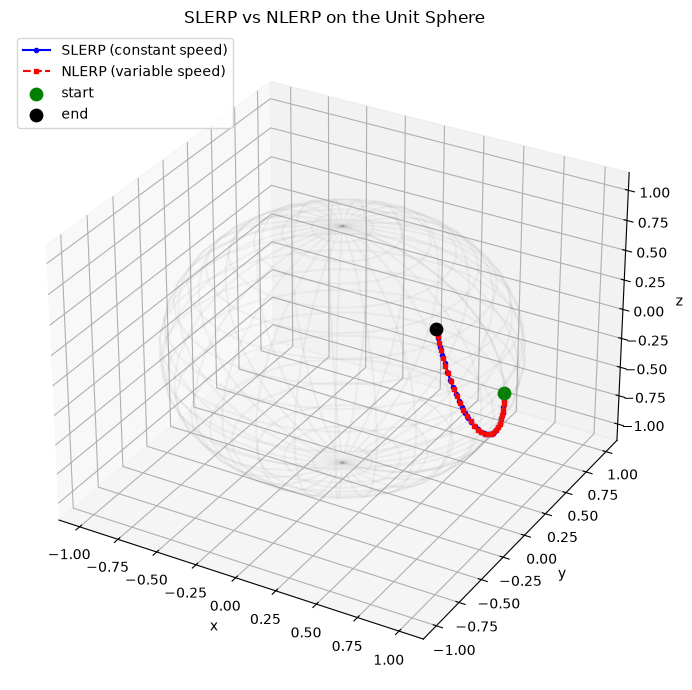

In [6]:
# SLERP vs LERP visualization
axis1 = np.array([0, 0, 1.0])
axis2 = np.array([1, 1, 0.0]); axis2 /= np.linalg.norm(axis2)
angle1, angle2 = 0.0, np.pi * 0.8

q0 = np.array([np.cos(angle1/2), *(np.sin(angle1/2)*axis1)])
q1 = np.array([np.cos(angle2/2), *(np.sin(angle2/2)*axis2)])

ts = np.linspace(0, 1, 30)
point = np.array([1.0, 0.0, 0.0])

slerp_pts, lerp_pts = [], []
for t in ts:
    # SLERP (using library)
    q_s = tf.slerp(q0, q1, t)
    slerp_pts.append(quat_to_matrix(q_s) @ point)
    # Naive LERP (normalize linear interpolation)
    q_l = (1-t)*q0 + t*q1
    q_l = q_l / np.linalg.norm(q_l)
    lerp_pts.append(quat_to_matrix(q_l) @ point)

slerp_pts = np.array(slerp_pts)
lerp_pts = np.array(lerp_pts)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Unit sphere wireframe
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  alpha=0.08, color='gray')

ax.plot(slerp_pts[:,0], slerp_pts[:,1], slerp_pts[:,2], 'b-o', ms=3,
        label='SLERP (constant speed)')
ax.plot(lerp_pts[:,0], lerp_pts[:,1], lerp_pts[:,2], 'r--s', ms=3,
        label='NLERP (variable speed)')
ax.scatter(*slerp_pts[0], c='green', s=80, zorder=5, label='start')
ax.scatter(*slerp_pts[-1], c='black', s=80, zorder=5, label='end')

ax.set_title('SLERP vs NLERP on the Unit Sphere')
ax.legend(loc='upper left')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

---
## 5. $\text{SE}(3)$ — Rigid Body Transformations

> **Notation:** In this notebook we use **P** for generic 3D points being transformed. Other notebooks follow the H&Z convention using **X** for world points and **x** for image points.

A rigid-body motion in 3-D consists of a rotation $R \in \text{SO}(3)$ and a
translation $\mathbf{t} \in \mathbb{R}^3$.  We embed this into a $4 \times 4$
**homogeneous transformation**:

$$
T = \begin{pmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{pmatrix} \in \text{SE}(3).
$$

### Composition

$$
T_1 \circ T_2 = T_1 T_2 = \begin{pmatrix} R_1 R_2 & R_1 \mathbf{t}_2 + \mathbf{t}_1 \\ \mathbf{0}^\top & 1 \end{pmatrix}.
$$

### Inverse (derivation)

We seek $T^{-1}$ such that $T T^{-1} = I$.  Let $T^{-1} = \bigl(\begin{smallmatrix} A & \mathbf{b} \\ \mathbf{0}^\top & 1 \end{smallmatrix}\bigr)$.  Then

$$
\begin{pmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{pmatrix}
\begin{pmatrix} A & \mathbf{b} \\ \mathbf{0}^\top & 1 \end{pmatrix}
= \begin{pmatrix} RA & R\mathbf{b} + \mathbf{t} \\ \mathbf{0}^\top & 1 \end{pmatrix}
= \begin{pmatrix} I & \mathbf{0} \\ \mathbf{0}^\top & 1 \end{pmatrix}.
$$

From $RA = I$ we get $A = R^{-1} = R^\top$.  From $R\mathbf{b} + \mathbf{t} = \mathbf{0}$ we get $\mathbf{b} = -R^\top \mathbf{t}$.

$$
\boxed{T^{-1} = \begin{pmatrix} R^\top & -R^\top \mathbf{t} \\ \mathbf{0}^\top & 1 \end{pmatrix}}
$$

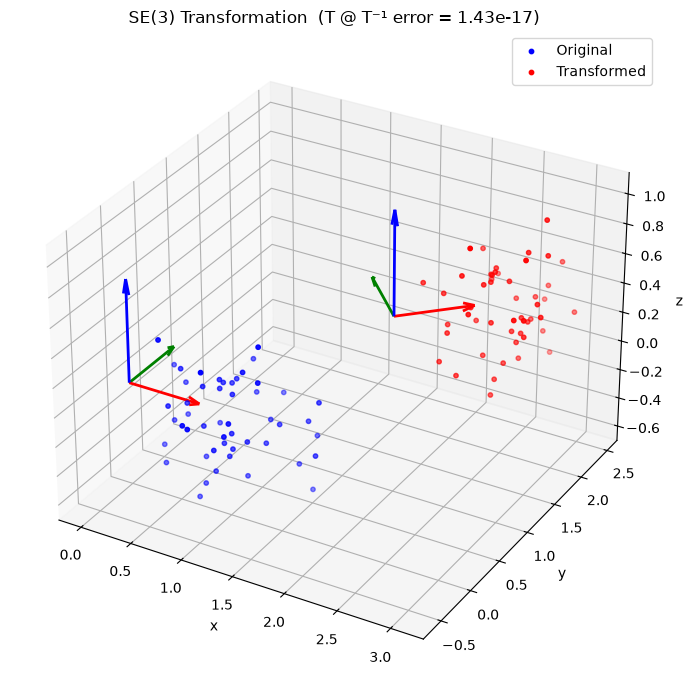

In [7]:
# Transform a point cloud, visualize before / after
np.random.seed(7)
cloud = np.random.randn(3, 50) * 0.3 + np.array([[1], [0], [0]])

R = rodrigues(np.array([0, 0, 1]), np.deg2rad(45))
t = np.array([2.0, 1.0, 0.5])
T = tf.se3_from_Rt(R, t)
T_inv = tf.se3_inverse(T)

# Apply T
cloud_h = np.vstack([cloud, np.ones((1, cloud.shape[1]))])
cloud_t = (T @ cloud_h)[:3]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(cloud[0], cloud[1], cloud[2], c='blue', s=10, label='Original')
ax.scatter(cloud_t[0], cloud_t[1], cloud_t[2], c='red', s=10, label='Transformed')

# Draw frames
def draw_frame(ax, T, length=0.5, lw=2):
    o = T[:3, 3]
    for i, c in enumerate(['r', 'g', 'b']):
        ax.quiver(*o, *T[:3, i]*length, color=c, linewidth=lw, arrow_length_ratio=0.15)

draw_frame(ax, np.eye(4), length=0.7)
draw_frame(ax, T, length=0.7)

# Verify inverse
err = np.linalg.norm(T @ T_inv - np.eye(4))
ax.set_title(f'SE(3) Transformation  (T @ T⁻¹ error = {err:.2e})')
ax.legend()
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

---
## 6. $\text{SO}(3)$ Lie Group Theory

### Why Lie groups?

Rotation matrices do **not** form a vector space. For example, if $R_1, R_2 \in \text{SO}(3)$,
their sum $R_1 + R_2$ is generally **not** in $\text{SO}(3)$.  This means we cannot do
standard calculus (gradients, optimization) directly on rotations.

The key insight of Lie theory: the **tangent space** at the identity — called the
**Lie algebra** $\mathfrak{so}(3)$ — *is* a vector space, and the **exponential map**
provides a bridge between the two.

### The Lie algebra $\mathfrak{so}(3)$

The Lie algebra of $\text{SO}(3)$ consists of $3 \times 3$ skew-symmetric matrices:

$$
\mathfrak{so}(3) = \{\, A \in \mathbb{R}^{3\times3} : A^\top = -A \,\}.
$$

Every element can be written as $[\boldsymbol{\omega}]_\times$ for some
$\boldsymbol{\omega} \in \mathbb{R}^3$.  The **hat** and **vee** operators convert
between the two representations:

$$
\boldsymbol{\omega}^\wedge = [\boldsymbol{\omega}]_\times \in \mathfrak{so}(3), \qquad
[\boldsymbol{\omega}]_\times^\vee = \boldsymbol{\omega} \in \mathbb{R}^3.
$$

### Exponential map: $\exp : \mathfrak{so}(3) \to \text{SO}(3)$

Let $\boldsymbol{\omega} = \theta\,\hat{\mathbf{k}}$ where $\theta = \|\boldsymbol{\omega}\|$
and $K = [\hat{\mathbf{k}}]_\times$ (unit-norm skew-symmetric). Start from the matrix exponential power series:

$$
\exp([\boldsymbol{\omega}]_\times) = \exp(\theta K) = \sum_{n=0}^{\infty} \frac{(\theta K)^n}{n!}
$$

The key identity is $K^3 = -K$ (since $K^2 = \hat{\mathbf{k}}\hat{\mathbf{k}}^\top - I$ and $K^3 = K(K^2) = K(\hat{\mathbf{k}}\hat{\mathbf{k}}^\top - I) = -K$). This means all powers of $K$ cycle: $K^{2m} = (-1)^{m+1} K^2$ and $K^{2m+1} = (-1)^m K$ for $m \geq 1$. Group the series into $I$, odd, and even powers:

$$
\exp(\theta K) = I + \underbrace{\left(\theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \cdots\right)}_{\sin\theta} K + \underbrace{\left(\frac{\theta^2}{2!} - \frac{\theta^4}{4!} + \frac{\theta^6}{6!} - \cdots\right)}_{1 - \cos\theta} K^2
$$

Substituting $K = [\boldsymbol{\omega}]_\times / \theta$:

$$
\boxed{\exp([\boldsymbol{\omega}]_\times) = I + \frac{\sin\theta}{\theta}[\boldsymbol{\omega}]_\times
  + \frac{1-\cos\theta}{\theta^2}[\boldsymbol{\omega}]_\times^2}
$$

This is exactly Rodrigues' formula (Section 3) with the angle absorbed into $\boldsymbol{\omega}$.

### Logarithm map: $\log : \text{SO}(3) \to \mathfrak{so}(3)$

Given $R$, recover $\boldsymbol{\omega}$:

1. $\theta = \arccos\!\left(\frac{\text{tr}(R) - 1}{2}\right)$

2. General case ($\theta \notin \{0, \pi\}$): $\boldsymbol{\omega} = \frac{\theta}{2\sin\theta}(R - R^\top)^\vee$

3. **$\theta \approx 0$**: Taylor expand $\frac{\theta}{2\sin\theta} \approx \frac{1}{2}$, so $\boldsymbol{\omega} \approx \frac{1}{2}(R - R^\top)^\vee$

4. **$\theta \approx \pi$**: $\sin\theta \approx 0$ makes the antisymmetric part vanish. Use $R + I = 2\hat{\mathbf{k}}\hat{\mathbf{k}}^\top$ and extract $\hat{\mathbf{k}}$ from the column of $R+I$ with the largest norm.

### Left Jacobian of $\text{SO}(3)$

The left Jacobian relates perturbations in the Lie algebra to perturbations on the group:

$$
\exp\!\bigl([\boldsymbol{\omega} + \delta\boldsymbol{\omega}]_\times\bigr)
\approx \exp\!\bigl([J_l\,\delta\boldsymbol{\omega}]_\times\bigr)\,\exp\!\bigl([\boldsymbol{\omega}]_\times\bigr).
$$

**Derivation (power-series route via BCH)**: The Baker-Campbell-Hausdorff formula gives:

$$\exp(A)\exp(B) = \exp\!\Bigl(A + B + \tfrac{1}{2}[A,B] + \tfrac{1}{12}\bigl([A,[A,B]] - [B,[A,B]]\bigr) + \cdots\Bigr)$$

Set $A = [\boldsymbol{\omega}]_\times$ and $B = [\delta\boldsymbol{\omega}]_\times$ with $\|\delta\boldsymbol{\omega}\| \ll 1$. Keeping only first-order terms in $\delta\boldsymbol{\omega}$:

$$\exp([\boldsymbol{\omega}]_\times)\exp([\delta\boldsymbol{\omega}]_\times)
\approx \exp\!\Bigl([\boldsymbol{\omega}]_\times + [\delta\boldsymbol{\omega}]_\times
+ \tfrac{1}{2}[[\boldsymbol{\omega}]_\times, [\delta\boldsymbol{\omega}]_\times]
+ \tfrac{1}{12}[[\boldsymbol{\omega}]_\times, [[\boldsymbol{\omega}]_\times, [\delta\boldsymbol{\omega}]_\times]]
+ \cdots\Bigr)$$

Using $[[\boldsymbol{\omega}]_\times, [\delta\boldsymbol{\omega}]_\times] = [\boldsymbol{\omega} \times \delta\boldsymbol{\omega}]_\times = [\boldsymbol{\omega}]_\times [\delta\boldsymbol{\omega}]_\times - [\delta\boldsymbol{\omega}]_\times [\boldsymbol{\omega}]_\times$, the $n$-th order term is $\frac{1}{(n+1)!}[\boldsymbol{\omega}]_\times^n [\delta\boldsymbol{\omega}]_\times$. Collecting:

$$\exp([\boldsymbol{\omega}]_\times)\exp([\delta\boldsymbol{\omega}]_\times)
\approx \exp\!\Bigl([(\boldsymbol{\omega} + J_l^{-1}\delta\boldsymbol{\omega})]_\times\Bigr)$$

Equivalently, $\exp([(\boldsymbol{\omega}+\delta\boldsymbol{\omega})]_\times) \approx \exp([J_l\,\delta\boldsymbol{\omega}]_\times)\exp([\boldsymbol{\omega}]_\times)$, with

$$
J_l(\boldsymbol{\omega}) = \sum_{n=0}^{\infty} \frac{1}{(n+1)!}[\boldsymbol{\omega}]_\times^n
= I + \frac{1}{2!}[\boldsymbol{\omega}]_\times + \frac{1}{3!}[\boldsymbol{\omega}]_\times^2 + \cdots
$$

**Derivation (integral route)**: Equivalently, $J_l$ arises as the integral of the matrix exponential:

$$
J_l(\boldsymbol{\omega}) = \int_0^1 \exp\!\bigl(t\,[\boldsymbol{\omega}]_\times\bigr)\,dt.
$$

Substituting Rodrigues' formula (with $\theta = \|\boldsymbol{\omega}\|$ and $K = [\hat{\boldsymbol{\omega}}]_\times = [\boldsymbol{\omega}]_\times / \theta$):

$$
\int_0^1 \exp\!\bigl(t\,[\boldsymbol{\omega}]_\times\bigr)\,dt
= \int_0^1 \!\Bigl[\,I + \sin(t\theta)\,K + \bigl(1-\cos(t\theta)\bigr)\,K^2\Bigr]dt.
$$

Evaluating each term:

$$
\int_0^1 \sin(t\theta)\,dt = \frac{1-\cos\theta}{\theta}, \qquad
\int_0^1 \bigl(1-\cos(t\theta)\bigr)\,dt = 1 - \frac{\sin\theta}{\theta} = \frac{\theta - \sin\theta}{\theta}.
$$

Substituting back and using $K = [\boldsymbol{\omega}]_\times/\theta$, $\;K^2 = [\boldsymbol{\omega}]_\times^2/\theta^2$:

$$
J_l = I + \frac{1-\cos\theta}{\theta}\cdot\frac{[\boldsymbol{\omega}]_\times}{\theta}
      + \frac{\theta-\sin\theta}{\theta}\cdot\frac{[\boldsymbol{\omega}]_\times^2}{\theta^2},
$$

which gives the closed form

$$
\boxed{J_l(\boldsymbol{\omega}) = I + \frac{1 - \cos\theta}{\theta^2}\,[\boldsymbol{\omega}]_\times
  + \frac{\theta - \sin\theta}{\theta^3}\,[\boldsymbol{\omega}]_\times^2}
$$

### Right Jacobian

$$
J_r(\boldsymbol{\omega}) = J_l(-\boldsymbol{\omega})
$$

In [8]:
def so3_exp(omega):
    """Exponential map: R^3 → SO(3)."""
    omega = np.asarray(omega, dtype=float)
    theta = np.linalg.norm(omega)
    K = skew(omega)
    if theta < 1e-8:
        return np.eye(3) + K
    a = np.sin(theta) / theta
    b = (1 - np.cos(theta)) / theta**2
    return np.eye(3) + a * K + b * (K @ K)

def so3_log(R):
    """Logarithm map: SO(3) → R^3."""
    R = np.asarray(R, dtype=float)
    cos_a = np.clip((np.trace(R) - 1) / 2, -1, 1)
    theta = np.arccos(cos_a)
    if theta < 1e-8:
        return 0.5 * np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]])
    if np.pi - theta < 1e-8:
        M = R + np.eye(3)
        col = np.argmax(np.sum(M**2, axis=0))
        axis = M[:, col]; axis /= np.linalg.norm(axis)
        return axis * theta
    f = theta / (2 * np.sin(theta))
    return f * np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]])

def so3_left_jacobian(omega):
    """Left Jacobian of SO(3)."""
    omega = np.asarray(omega, dtype=float)
    theta = np.linalg.norm(omega)
    K = skew(omega)
    if theta < 1e-8:
        return np.eye(3) + 0.5 * K
    a = (1 - np.cos(theta)) / theta**2
    b = (theta - np.sin(theta)) / theta**3
    return np.eye(3) + a * K + b * (K @ K)

def so3_right_jacobian(omega):
    """Right Jacobian: J_r(ω) = J_l(-ω)."""
    return so3_left_jacobian(-np.asarray(omega, dtype=float))

# Verify exp(log(R)) = R for random rotations
print("Verifying exp(log(R)) = R for 5 random rotations:")
for i in range(5):
    omega_rand = np.random.randn(3) * 2
    R_rand = so3_exp(omega_rand)
    omega_rec = so3_log(R_rand)
    R_rec = so3_exp(omega_rec)
    err = np.linalg.norm(R_rand - R_rec)
    print(f"  Trial {i+1}: ‖R - exp(log(R))‖ = {err:.2e}")

# Verify Jacobian: J_l @ J_r^T ≈ exp([ω]×) for the left-right relationship
omega_test = np.array([0.3, -0.5, 0.8])
Jl = so3_left_jacobian(omega_test)
Jr = so3_right_jacobian(omega_test)
R_test = so3_exp(omega_test)
print(f"\nJ_l = R @ J_r?  Error: {np.linalg.norm(Jl - R_test @ Jr):.2e}")

Verifying exp(log(R)) = R for 5 random rotations:
  Trial 1: ‖R - exp(log(R))‖ = 6.38e-15
  Trial 2: ‖R - exp(log(R))‖ = 4.64e-16
  Trial 3: ‖R - exp(log(R))‖ = 8.40e-16
  Trial 4: ‖R - exp(log(R))‖ = 2.36e-14
  Trial 5: ‖R - exp(log(R))‖ = 4.71e-16

J_l = R @ J_r?  Error: 1.42e-16


---
## 7. $\text{SE}(3)$ Lie Group Theory

### The Lie algebra $\mathfrak{se}(3)$

A twist $\boldsymbol{\xi} \in \mathbb{R}^6$ has two parts:

$$
\boldsymbol{\xi} = \begin{pmatrix} \boldsymbol{\rho} \\ \boldsymbol{\omega} \end{pmatrix} \in \mathbb{R}^6
$$

where $\boldsymbol{\rho} \in \mathbb{R}^3$ is the translational part and
$\boldsymbol{\omega} \in \mathbb{R}^3$ the rotational part.  Its matrix representation is

$$
\boldsymbol{\xi}^\wedge = \begin{pmatrix} [\boldsymbol{\omega}]_\times & \boldsymbol{\rho} \\ \mathbf{0}^\top & 0 \end{pmatrix} \in \mathfrak{se}(3).
$$

### $\text{SE}(3)$ exponential map

$$
T = \exp\!\bigl(\boldsymbol{\xi}^\wedge\bigr) = \begin{pmatrix}
  \exp([\boldsymbol{\omega}]_\times) & V\,\boldsymbol{\rho} \\
  \mathbf{0}^\top & 1
\end{pmatrix}
$$

where the $V$ matrix has the *same form* as the SO(3) left Jacobian:

$$
V = I + \frac{1-\cos\theta}{\theta^2}\,[\boldsymbol{\omega}]_\times + \frac{\theta - \sin\theta}{\theta^3}\,[\boldsymbol{\omega}]_\times^2.
$$

**Why is $V = J_l$?**  The SE(3) exponential arises from integrating the differential equation
$\dot{T} = \boldsymbol{\xi}^\wedge T$.  The rotation part decouples and gives $\exp([\boldsymbol{\omega}]_\times)$.
The translation part involves the integral $\int_0^1 \exp(s[\boldsymbol{\omega}]_\times)\,ds$,
which is exactly the left Jacobian.

### $\text{SE}(3)$ logarithm map

Given $T = \bigl(\begin{smallmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{smallmatrix}\bigr)$:

1. $\boldsymbol{\omega} = \log(R)$ via the SO(3) log map
2. $\boldsymbol{\rho} = V^{-1} \mathbf{t}$

where

$$
V^{-1} = I - \frac{1}{2}[\boldsymbol{\omega}]_\times
  + \frac{1}{\theta^2}\left(1 - \frac{\theta\sin\theta}{2(1-\cos\theta)}\right)[\boldsymbol{\omega}]_\times^2.
$$

### Adjoint representation

The **adjoint** of $T \in \text{SE}(3)$ is the $6 \times 6$ matrix that transforms twists
between coordinate frames:

$$
\text{Ad}_T = \begin{pmatrix} R & [\mathbf{t}]_\times R \\ \mathbf{0}_{3\times3} & R \end{pmatrix} \in \mathbb{R}^{6\times6}.
$$

If $\boldsymbol{\xi}_a$ is a twist in frame $a$, then the same motion in frame $b$ (where
$T$ transforms from $a$ to $b$) is

$$
\boldsymbol{\xi}_b = \text{Ad}_T \, \boldsymbol{\xi}_a.
$$

In [9]:
# SE(3) exp / log round-trip
xi = np.array([0.5, -0.3, 0.8, 0.2, -0.4, 0.6])  # [rho; omega]
T = tf.se3_exp(xi)
xi_rec = tf.se3_log(T)
T_rec = tf.se3_exp(xi_rec)

print("SE(3) exp/log round-trip:")
print(f"  ξ original:  {xi.round(4)}")
print(f"  ξ recovered: {xi_rec.round(4)}")
print(f"  ‖T - exp(log(T))‖ = {np.linalg.norm(T - T_rec):.2e}")

# Adjoint: transform a twist between frames
Ad_T = tf.se3_adjoint(T)
xi_frame_a = np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.1])
xi_frame_b = Ad_T @ xi_frame_a
print(f"\nAdjoint (6×6) shape: {Ad_T.shape}")
print(f"Twist in frame a: {xi_frame_a}")
print(f"Twist in frame b: {xi_frame_b.round(4)}")

# Verify adjoint property: Ad(T1 T2) = Ad(T1) Ad(T2)
T1 = tf.se3_exp(np.random.randn(6) * 0.5)
T2 = tf.se3_exp(np.random.randn(6) * 0.5)
Ad_12 = tf.se3_adjoint(T1 @ T2)
Ad_1_Ad_2 = tf.se3_adjoint(T1) @ tf.se3_adjoint(T2)
print(f"\nAd(T₁T₂) = Ad(T₁)Ad(T₂)?  Error: {np.linalg.norm(Ad_12 - Ad_1_Ad_2):.2e}")

SE(3) exp/log round-trip:
  ξ original:  [ 0.5 -0.3  0.8  0.2 -0.4  0.6]
  ξ recovered: [ 0.5 -0.3  0.8  0.2 -0.4  0.6]
  ‖T - exp(log(T))‖ = 2.78e-16

Adjoint (6×6) shape: (6, 6)
Twist in frame a: [1.  0.  0.  0.  0.  0.1]
Twist in frame b: [ 0.7547  0.4438  0.4011 -0.0306 -0.0296  0.0905]

Ad(T₁T₂) = Ad(T₁)Ad(T₂)?  Error: 2.56e-16


### 7.1 $\text{SE}(3)$ Left Jacobian — Full $6 \times 6$ Derivation

The SO(3) left Jacobian $J_l(\boldsymbol{\phi})$ was derived in Section 6. We now extend
it to the full $6 \times 6$ left Jacobian of $\text{SE}(3)$.

**Setup.** For $\boldsymbol{\xi} = (\boldsymbol{\rho},\, \boldsymbol{\phi})^\top \in \mathbb{R}^6$,
the SE(3) left Jacobian satisfies

$$
\exp\!\bigl((\boldsymbol{\xi} + \delta\boldsymbol{\xi})^\wedge\bigr) \approx
\exp\!\bigl((\mathcal{J}_l\,\delta\boldsymbol{\xi})^\wedge\bigr)\,
\exp\!\bigl(\boldsymbol{\xi}^\wedge\bigr).
$$

**Power-series definition.** The Lie-algebra adjoint (small adjoint) of
$\boldsymbol{\xi}$ has the block form

$$
\text{ad}(\boldsymbol{\xi}) =
\begin{pmatrix} [\boldsymbol{\phi}]_\times & [\boldsymbol{\rho}]_\times \\
\mathbf{0} & [\boldsymbol{\phi}]_\times \end{pmatrix} \in \mathbb{R}^{6\times6}.
$$

The SE(3) left Jacobian is defined by the same series as for SO(3), but using this $6\times6$ adjoint:

$$
\mathcal{J}_l(\boldsymbol{\xi}) = \sum_{n=0}^{\infty} \frac{1}{(n+1)!}\,\text{ad}(\boldsymbol{\xi})^n.
$$

**Deriving the block structure.** Since $\text{ad}(\boldsymbol{\xi})$ is block upper-triangular,
its powers preserve that structure:

$$
\text{ad}(\boldsymbol{\xi})^n =
\begin{pmatrix} [\boldsymbol{\phi}]_\times^n & S_n \\
\mathbf{0} & [\boldsymbol{\phi}]_\times^n \end{pmatrix}
$$

where $S_0 = 0$, $S_1 = [\boldsymbol{\rho}]_\times$, and the recursion is
$S_{n} = [\boldsymbol{\phi}]_\times\,S_{n-1} + [\boldsymbol{\rho}]_\times\,[\boldsymbol{\phi}]_\times^{n-1}$.

> **Derivation of the recursion.** From $\text{ad}^{n+1} = \text{ad} \cdot \text{ad}^n$, the top-right block gives
> $S_{n+1} = [\boldsymbol{\phi}]_\times S_n + [\boldsymbol{\rho}]_\times [\boldsymbol{\phi}]_\times^n$.
> Shifting the index: $S_n = [\boldsymbol{\phi}]_\times S_{n-1} + [\boldsymbol{\rho}]_\times [\boldsymbol{\phi}]_\times^{n-1}$.
> Note that $[\boldsymbol{\rho}]_\times [\boldsymbol{\phi}]_\times^{n-1} \neq [\boldsymbol{\phi}]_\times^{n-1} [\boldsymbol{\rho}]_\times$ in general (matrix multiplication is non-commutative).

Summing the series block-by-block:

$$
\boxed{\mathcal{J}_l(\boldsymbol{\xi}) =
\begin{pmatrix} J_l(\boldsymbol{\phi}) & Q(\boldsymbol{\phi},\,\boldsymbol{\rho}) \\
\mathbf{0}_{3\times3} & J_l(\boldsymbol{\phi}) \end{pmatrix}}
$$

where the $(1,1)$ and $(2,2)$ blocks are the SO(3) left Jacobian $J_l(\boldsymbol{\phi}) = \sum \frac{[\boldsymbol{\phi}]_\times^n}{(n+1)!}$, and the
**Q matrix** is

$$
Q(\boldsymbol{\phi},\,\boldsymbol{\rho}) = \sum_{n=1}^{\infty} \frac{S_n}{(n+1)!}.
$$

**Connection to the SE(3) exponential.** The translation part of $\exp(\boldsymbol{\xi}^\wedge)$ is

$$
\mathbf{t} = V\,\boldsymbol{\rho}, \qquad V = J_l(\boldsymbol{\phi}),
$$

i.e., the matrix $V$ that converts the twist's translational component $\boldsymbol{\rho}$ into the
actual translation $\mathbf{t}$ is exactly the SO(3) left Jacobian of the rotational part
$\boldsymbol{\phi}$. This arises because $V = \int_0^1 \exp(s\,[\boldsymbol{\phi}]_\times)\,ds = J_l(\boldsymbol{\phi})$ — the same integral derived in Section 6.

In [10]:
def se3_small_adjoint(xi):
    """Small adjoint ad(xi) of a twist xi = [rho; phi] ∈ R^6."""
    rho, phi = xi[:3], xi[3:]
    ad = np.zeros((6, 6))
    ad[:3, :3] = skew(phi)
    ad[:3, 3:] = skew(rho)
    ad[3:, 3:] = skew(phi)
    return ad

def se3_left_jacobian(xi, N=40):
    """
    6×6 SE(3) left Jacobian via truncated power series.

    J_l(xi) = sum_{n=0}^{N} ad(xi)^n / (n+1)!
    """
    ad = se3_small_adjoint(xi)
    J = np.eye(6)
    ad_n = np.eye(6)
    for n in range(1, N + 1):
        ad_n = ad_n @ ad / (n + 1)
        J += ad_n
    return J

# --- Verify block structure ---
xi_test = np.array([0.5, -0.3, 0.8, 0.2, -0.4, 0.6])
phi_test = xi_test[3:]
rho_test = xi_test[:3]

Jl_se3 = se3_left_jacobian(xi_test)
Jl_so3 = so3_left_jacobian(phi_test)

print("SE(3) left Jacobian (6×6):")
print(Jl_se3.round(4))

print(f"\n--- Block structure verification ---")
print(f"  Top-left  = J_l(φ)?  Error: {np.linalg.norm(Jl_se3[:3,:3] - Jl_so3):.2e}")
print(f"  Bot-right = J_l(φ)?  Error: {np.linalg.norm(Jl_se3[3:,3:] - Jl_so3):.2e}")
print(f"  Bot-left  = 0?       Error: {np.linalg.norm(Jl_se3[3:,:3]):.2e}")
print(f"  Top-right = Q ≠ 0?   Norm:  {np.linalg.norm(Jl_se3[:3,3:]):.4f}")

# --- Verify t = V ρ = J_l(φ) ρ ---
T_from_exp = tf.se3_exp(xi_test)
t_actual = T_from_exp[:3, 3]
t_from_Jl = Jl_so3 @ rho_test
print(f"\n--- Translation: t = J_l(φ) ρ ---")
print(f"  t from exp(ξ^):  {t_actual.round(6)}")
print(f"  t from J_l(φ)ρ:  {t_from_Jl.round(6)}")
print(f"  Error: {np.linalg.norm(t_actual - t_from_Jl):.2e}")

# --- Finite-difference verification of the full 6×6 Jacobian ---
eps = 1e-7
T_base = tf.se3_exp(xi_test)
Jl_fd = np.zeros((6, 6))

for j in range(6):
    dxi = np.zeros(6)
    dxi[j] = eps
    T_pert = tf.se3_exp(xi_test + dxi)
    delta_T = T_pert @ np.linalg.inv(T_base)
    delta_xi = tf.se3_log(delta_T)
    Jl_fd[:, j] = delta_xi / eps

print(f"\n--- Finite-difference check ---")
print(f"  ‖J_l(analytic) − J_l(finite-diff)‖ = {np.linalg.norm(Jl_se3 - Jl_fd):.2e}")
print("\n✓ SE(3) 6×6 left Jacobian verified.")

SE(3) left Jacobian (6×6):
[[ 0.9157 -0.2992 -0.1714 -0.1886 -0.3892 -0.0475]
 [ 0.2733  0.9352 -0.1343  0.3067 -0.1834 -0.3056]
 [ 0.2103  0.0565  0.9676  0.1938  0.149  -0.069 ]
 [ 0.      0.      0.      0.9157 -0.2992 -0.1714]
 [ 0.      0.      0.      0.2733  0.9352 -0.1343]
 [ 0.      0.      0.      0.2103  0.0565  0.9676]]

--- Block structure verification ---
  Top-left  = J_l(φ)?  Error: 1.95e-16
  Bot-right = J_l(φ)?  Error: 1.95e-16
  Bot-left  = 0?       Error: 0.00e+00
  Top-right = Q ≠ 0?   Norm:  0.6892

--- Translation: t = J_l(φ) ρ ---
  t from exp(ξ^):  [ 0.410518 -0.251357  0.862256]
  t from J_l(φ)ρ:  [ 0.410518 -0.251357  0.862256]
  Error: 0.00e+00

--- Finite-difference check ---
  ‖J_l(analytic) − J_l(finite-diff)‖ = 1.33e-08

✓ SE(3) 6×6 left Jacobian verified.


### 7.2 Adjoint Representation — Derivation

The adjoint formula
$\text{Ad}_T = \bigl(\begin{smallmatrix} R & [t]_\times R \\ 0 & R \end{smallmatrix}\bigr)$
was stated in Section 7 and verified numerically. We now derive it from the definition.

**Definition.** The adjoint maps a twist from one frame to another via conjugation:

$$
\text{Ad}_T\,\boldsymbol{\xi} = \bigl(T\,\exp(\boldsymbol{\xi}^\wedge)\,T^{-1}\bigr)^\vee \Big|_{\text{linearized at } \boldsymbol{\xi}=0}
$$

More precisely, $\exp\!\bigl((\text{Ad}_T\,\boldsymbol{\xi})^\wedge\bigr) = T\,\exp(\boldsymbol{\xi}^\wedge)\,T^{-1}$
for all $\boldsymbol{\xi}$.

**Derivation.** Let $T = \bigl(\begin{smallmatrix} R & \mathbf{t} \\ 0 & 1 \end{smallmatrix}\bigr)$
and $\boldsymbol{\xi} = (\boldsymbol{\rho}, \boldsymbol{\phi})$, so
$\boldsymbol{\xi}^\wedge = \bigl(\begin{smallmatrix} [\boldsymbol{\phi}]_\times & \boldsymbol{\rho} \\ 0 & 0 \end{smallmatrix}\bigr)$.

**Step 1.** Compute $T\,\boldsymbol{\xi}^\wedge\,T^{-1}$ directly:

$$
T\,\boldsymbol{\xi}^\wedge\,T^{-1}
= \begin{pmatrix} R & \mathbf{t} \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} [\boldsymbol{\phi}]_\times & \boldsymbol{\rho} \\ 0 & 0 \end{pmatrix}
\begin{pmatrix} R^\top & -R^\top\mathbf{t} \\ 0 & 1 \end{pmatrix}.
$$

**Step 2.** Multiply the first two matrices:

$$
\begin{pmatrix} R[\boldsymbol{\phi}]_\times & R\boldsymbol{\rho} \\ 0 & 0 \end{pmatrix}.
$$

**Step 3.** Multiply by $T^{-1}$:

$$
\begin{pmatrix}
  R[\boldsymbol{\phi}]_\times R^\top & -R[\boldsymbol{\phi}]_\times R^\top\mathbf{t} + R\boldsymbol{\rho} \\
  0 & 0
\end{pmatrix}.
$$

**Step 4.** Use the identity $R[\boldsymbol{\phi}]_\times R^\top = [R\boldsymbol{\phi}]_\times$
(rotation of a cross product). The result is an element of $\mathfrak{se}(3)$:

$$
T\,\boldsymbol{\xi}^\wedge\,T^{-1}
= \begin{pmatrix} [R\boldsymbol{\phi}]_\times & R\boldsymbol{\rho} + [\mathbf{t}]_\times R\boldsymbol{\phi} \\ 0 & 0 \end{pmatrix}
= \begin{pmatrix} R\boldsymbol{\rho} + [\mathbf{t}]_\times R\boldsymbol{\phi} \\ R\boldsymbol{\phi} \end{pmatrix}^\wedge
$$

where we used $-[R\boldsymbol{\phi}]_\times\mathbf{t} = [\mathbf{t}]_\times R\boldsymbol{\phi}$
(since $\mathbf{a}\times\mathbf{b} = -\mathbf{b}\times\mathbf{a}$).

**Step 5.** Read off the $6 \times 6$ matrix:

$$
\begin{pmatrix} \boldsymbol{\rho}' \\ \boldsymbol{\phi}' \end{pmatrix}
= \underbrace{\begin{pmatrix} R & [\mathbf{t}]_\times R \\ \mathbf{0} & R \end{pmatrix}}_{\text{Ad}_T}
\begin{pmatrix} \boldsymbol{\rho} \\ \boldsymbol{\phi} \end{pmatrix}.
\quad \square
$$

In [11]:
# Verify the adjoint derivation step-by-step
xi_adj = np.array([0.4, -0.2, 0.7, 0.3, -0.5, 0.6])
T_adj = tf.se3_exp(np.random.RandomState(99).randn(6) * 0.8)
R_adj = T_adj[:3, :3]
t_adj = T_adj[:3, 3]

# Method 1: direct conjugation  T exp(ξ^) T^{-1}  → extract twist
T_conj = T_adj @ tf.se3_exp(xi_adj) @ tf.se3_inverse(T_adj)
xi_conj = tf.se3_log(T_conj)

# Method 2: Ad_T @ ξ  using the derived formula
Ad_T_derived = np.zeros((6, 6))
Ad_T_derived[:3, :3] = R_adj
Ad_T_derived[:3, 3:] = skew(t_adj) @ R_adj
Ad_T_derived[3:, 3:] = R_adj
xi_adjoint = Ad_T_derived @ xi_adj

print("--- Adjoint derivation verification ---")
print(f"  Via conjugation:  {xi_conj.round(6)}")
print(f"  Via Ad_T formula: {xi_adjoint.round(6)}")
print(f"  Error: {np.linalg.norm(xi_conj - xi_adjoint):.2e}")

# Cross-check with library
Ad_lib = tf.se3_adjoint(T_adj)
print(f"\n  Library Ad_T matches derived?  Error: {np.linalg.norm(Ad_lib - Ad_T_derived):.2e}")

# Verify key identity used in the derivation: R [φ]× R^T = [Rφ]×
phi_check = np.array([0.3, -0.5, 0.6])
lhs = R_adj @ skew(phi_check) @ R_adj.T
rhs = skew(R_adj @ phi_check)
print(f"\n  R[φ]×Rᵀ = [Rφ]×?  Error: {np.linalg.norm(lhs - rhs):.2e}")

print("\n✓ Adjoint representation derivation verified.")

--- Adjoint derivation verification ---
  Via conjugation:  [ 0.927702 -0.539472  0.002383  0.227963 -0.794891 -0.127203]
  Via Ad_T formula: [ 0.927702 -0.539472  0.002383  0.227963 -0.794891 -0.127203]
  Error: 1.60e-16

  Library Ad_T matches derived?  Error: 0.00e+00

  R[φ]×Rᵀ = [Rφ]×?  Error: 1.54e-16

✓ Adjoint representation derivation verified.


### 7.3 Camera Coordinate Conventions

Different software ecosystems use different conventions for camera coordinate axes. Mixing
them up is one of the most common sources of bugs in 3-D vision pipelines.

| Convention | $X$ | $Y$ | $Z$ | Used by |
|:-----------|:----|:----|:----|:--------|
| **OpenCV** | right | down | forward (into scene) | OpenCV, COLMAP, most SfM/SLAM |
| **OpenGL / Blender** | right | up | backward (out of scene) | OpenGL, Blender, Three.js, NeRF |
| **ROS / Robotics** | forward | left | up | ROS, Gazebo, many robotics stacks |

### Converting Between Conventions

Going from one convention to another is a pure rotation (no translation). The key matrices:

**OpenCV → OpenGL** ($Y$ and $Z$ flip):

$$
R_{\text{cv}\to\text{gl}} = \begin{pmatrix} 1 & 0 & 0 \\ 0 & -1 & 0 \\ 0 & 0 & -1 \end{pmatrix}
$$

**OpenCV → ROS** (cycle $X\to Z$, $Y\to{-X}$, $Z\to{-Y}$):

$$
R_{\text{cv}\to\text{ros}} = \begin{pmatrix} 0 & 0 & 1 \\ -1 & 0 & 0 \\ 0 & -1 & 0 \end{pmatrix}
$$

**OpenGL → ROS**:

$$
R_{\text{gl}\to\text{ros}} = R_{\text{cv}\to\text{ros}}\,R_{\text{cv}\to\text{gl}}^{-1}
$$

### Common Pitfall: World-to-Camera vs Camera-to-World

Two equally valid ways to describe a camera's pose:

| Matrix | Meaning | Notation |
|:-------|:--------|:---------|
| $T_{cw}$ (world-to-camera) | Transforms **world points** into the camera frame | Used in projection: $\mathbf{x} = K\,[R \mid t]\,\mathbf{X}_w$ |
| $T_{wc}$ (camera-to-world) | Transforms **camera-frame points** into the world | $T_{wc} = T_{cw}^{-1}$; the camera center is $T_{wc}[:3, 3]$ |

> **Rule of thumb:** COLMAP and most SfM systems store $T_{cw}$ (world-to-camera).
> Blender and many visualization tools expect $T_{wc}$ (camera-to-world).
> Always check the convention before plugging in a pose — getting this wrong flips the entire scene.

Convention conversion matrices:

R_cv→gl (flip Y,Z):
[[ 1  0  0]
 [ 0 -1  0]
 [ 0  0 -1]]

R_cv→ros:
[[ 0  0  1]
 [-1  0  0]
 [ 0 -1  0]]

R_gl→ros:
[[ 0  0 -1]
 [-1  0  0]
 [ 0  1  0]]

✓ All conversion matrices are valid rotations (det = +1, RᵀR = I).

--- World-to-Camera vs Camera-to-World ---
  Camera center (from T_wc): [-3.3558 -2.0084 -3.8347]
  Camera center (from -Rᵀt): [-3.3558 -2.0084 -3.8347]
  Match? True

--- Same world point in different camera frames ---
  OpenCV cam coords:  [ 0.4412  2.2016 13.5818]  (Z forward = depth)
  OpenGL cam coords:  [  0.4412  -2.2016 -13.5818]  (Z backward)
  OpenCV Z = -OpenGL Z?  True


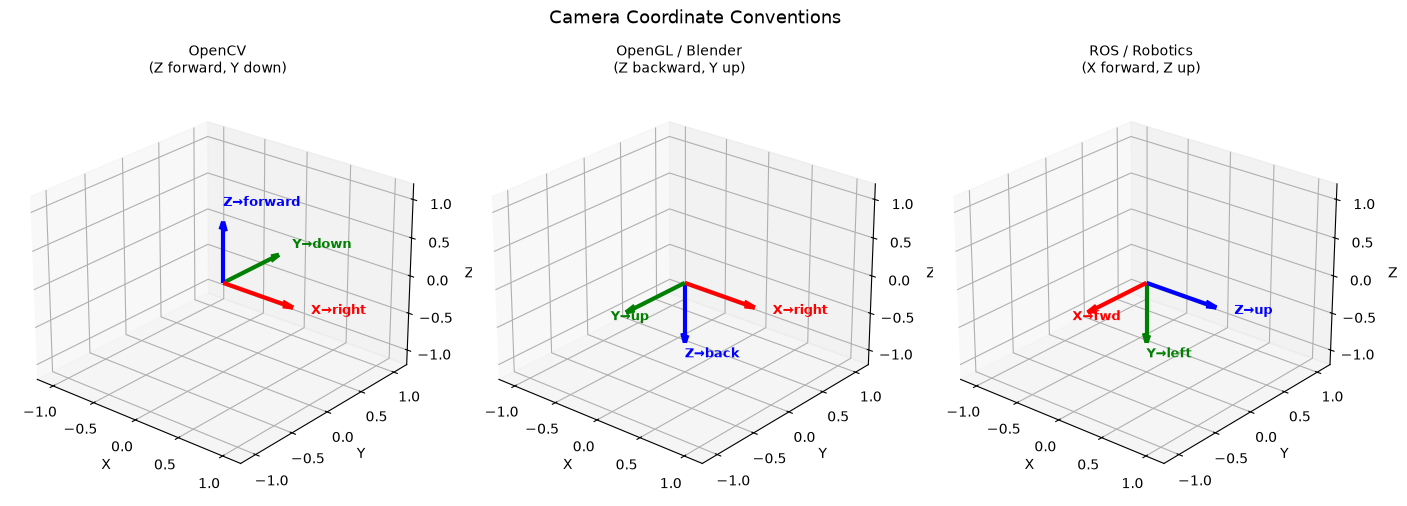

In [12]:
# --- Conversion matrices between camera conventions ---

R_cv_to_gl = np.diag([1.0, -1.0, -1.0])       # OpenCV → OpenGL: flip Y and Z
R_gl_to_cv = R_cv_to_gl.T                       # its own inverse (symmetric)

R_cv_to_ros = np.array([                         # OpenCV → ROS
    [0,  0, 1],
    [-1, 0, 0],
    [0, -1, 0],
], dtype=float)
R_ros_to_cv = R_cv_to_ros.T

R_gl_to_ros = R_cv_to_ros @ R_gl_to_cv          # OpenGL → ROS

print("Convention conversion matrices:")
print(f"\nR_cv→gl (flip Y,Z):\n{R_cv_to_gl.astype(int)}")
print(f"\nR_cv→ros:\n{R_cv_to_ros.astype(int)}")
print(f"\nR_gl→ros:\n{R_gl_to_ros.astype(int)}")

# Verify all are proper rotations
for name, R in [("cv→gl", R_cv_to_gl), ("cv→ros", R_cv_to_ros), ("gl→ros", R_gl_to_ros)]:
    assert is_rotation_matrix(R), f"{name} is not SO(3)!"
print("\n✓ All conversion matrices are valid rotations (det = +1, RᵀR = I).")

# --- Demonstrate: same camera pose, different conventions ---
R_cam_cv = rodrigues(np.array([0.1, -0.3, 0.2]), 0.5)
t_cam_cv = np.array([1.0, 2.0, 5.0])

# World-to-camera in OpenCV convention
T_cw_cv = tf.se3_from_Rt(R_cam_cv, t_cam_cv)

# Camera-to-world (inverse)
T_wc_cv = tf.se3_inverse(T_cw_cv)
camera_center = T_wc_cv[:3, 3]

print(f"\n--- World-to-Camera vs Camera-to-World ---")
print(f"  Camera center (from T_wc): {camera_center.round(4)}")
print(f"  Camera center (from -Rᵀt): {(-R_cam_cv.T @ t_cam_cv).round(4)}")
print(f"  Match? {np.allclose(camera_center, -R_cam_cv.T @ t_cam_cv)}")

# Convert the same pose to OpenGL convention
R_cam_gl = R_cv_to_gl @ R_cam_cv
t_cam_gl = R_cv_to_gl @ t_cam_cv
T_cw_gl = tf.se3_from_Rt(R_cam_gl, t_cam_gl)

# A point in world coords should project the same way through both
P_world = np.array([3.0, 1.0, 8.0, 1.0])
P_cam_cv = T_cw_cv @ P_world
P_cam_gl = T_cw_gl @ P_world

print(f"\n--- Same world point in different camera frames ---")
print(f"  OpenCV cam coords:  {P_cam_cv[:3].round(4)}  (Z forward = depth)")
print(f"  OpenGL cam coords:  {P_cam_gl[:3].round(4)}  (Z backward)")
print(f"  OpenCV Z = -OpenGL Z?  {np.allclose(P_cam_cv[2], -P_cam_gl[2])}")

# Visualize the three conventions
fig = plt.figure(figsize=(14, 5))
conventions = [
    ("OpenCV\n(Z forward, Y down)", np.eye(3), ['X→right','Y→down','Z→forward']),
    ("OpenGL / Blender\n(Z backward, Y up)", R_cv_to_gl, ['X→right','Y→up','Z→back']),
    ("ROS / Robotics\n(X forward, Z up)", R_cv_to_ros, ['X→fwd','Y→left','Z→up']),
]
axis_colors = ['r', 'g', 'b']

for idx, (title, R_conv, labels) in enumerate(conventions):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    origin = np.zeros(3)
    for j in range(3):
        direction = R_conv[:, j]
        ax.quiver(*origin, *direction * 0.8, color=axis_colors[j],
                  linewidth=3, arrow_length_ratio=0.15)
        ax.text(*(direction * 1.0), labels[j], color=axis_colors[j],
                fontsize=9, fontweight='bold')
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_zlim(-1.2, 1.2)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=25, azim=-50)

plt.suptitle('Camera Coordinate Conventions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Exercises

Below are self-contained exercises that tie together the concepts from every section.

### Exercise (a): Gimbal Lock Demo

Rotate a point cloud with Euler angles, sweeping pitch through 90° to show how yaw and roll
become indistinguishable.

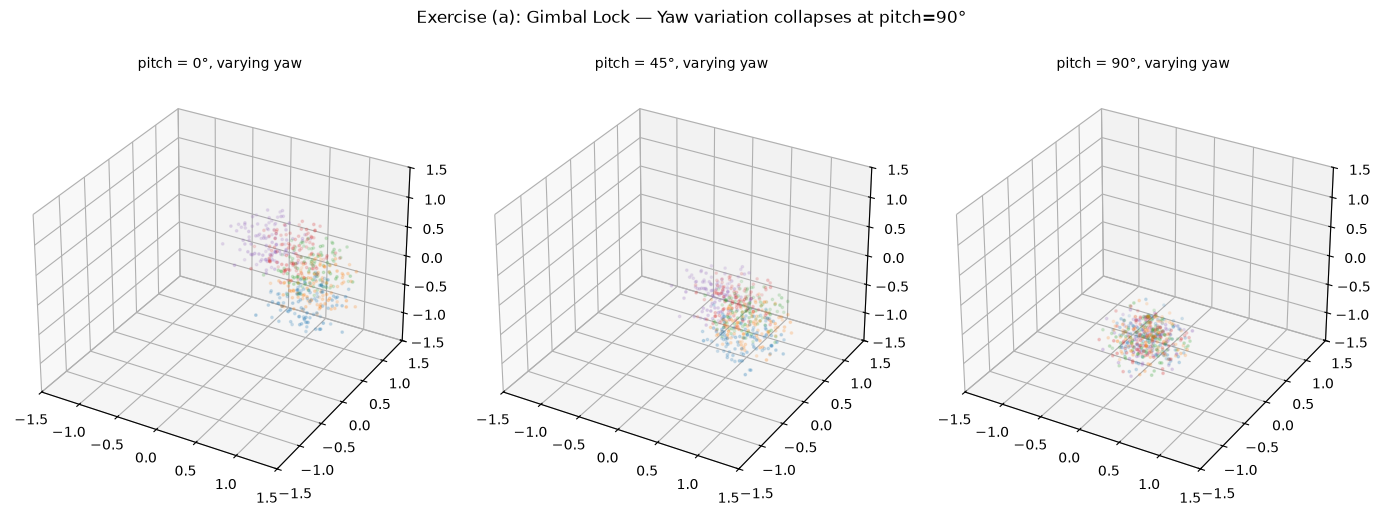

In [13]:
np.random.seed(0)
cloud = np.random.randn(3, 100) * 0.2 + np.array([[1], [0], [0]])

fig = plt.figure(figsize=(14, 5))
pitches = [0, 45, 90]

for idx, pitch_deg in enumerate(pitches):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    pitch = np.deg2rad(pitch_deg)
    for yaw_deg in np.linspace(0, 90, 5):
        R = tf.rotation_matrix_from_euler(np.deg2rad(30), pitch, np.deg2rad(yaw_deg))
        pts = R @ cloud
        ax.scatter(pts[0], pts[1], pts[2], s=3, alpha=0.5)
    ax.set_title(f'pitch = {pitch_deg}°, varying yaw', fontsize=10)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_zlim(-1.5, 1.5)

plt.suptitle('Exercise (a): Gimbal Lock — Yaw variation collapses at pitch=90°',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Exercise (b): Spiral Camera Trajectory

Compose 100 camera poses along a spiral path and draw each coordinate frame (RGB = XYZ axes).

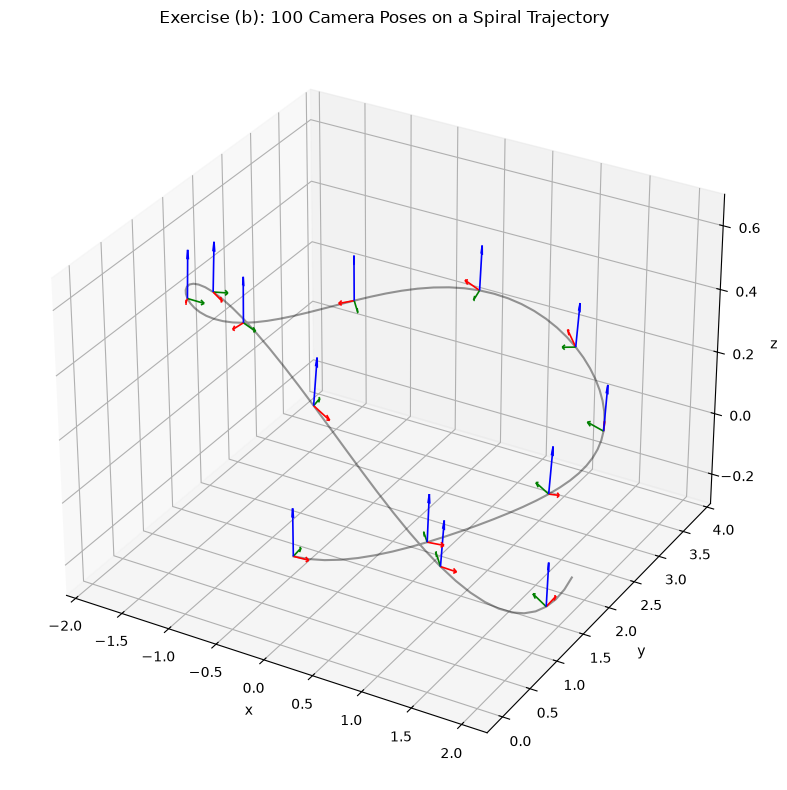

In [14]:
N = 100
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

positions = []
T_curr = np.eye(4)

for i in range(N):
    s = i / N
    # Spiral: gentle yaw + slight pitch + rising translation
    d_yaw = 0.08
    d_pitch = 0.02 * np.sin(2 * np.pi * s * 3)
    R_step = tf.rotation_matrix_from_euler(0, d_pitch, d_yaw)
    t_step = np.array([0.15, 0.0, 0.03 * np.sin(2 * np.pi * s * 2)])
    T_step = tf.se3_from_Rt(R_step, t_step)
    T_curr = tf.se3_compose(T_curr, T_step)
    positions.append(T_curr[:3, 3].copy())

    if i % 8 == 0:
        o = T_curr[:3, 3]
        for j, c in enumerate(['r', 'g', 'b']):
            ax.quiver(o[0], o[1], o[2],
                      T_curr[0,j]*0.15, T_curr[1,j]*0.15, T_curr[2,j]*0.15,
                      color=c, linewidth=1.2, arrow_length_ratio=0.2)

positions = np.array(positions)
ax.plot(positions[:,0], positions[:,1], positions[:,2], 'k-', alpha=0.4)
ax.set_title('Exercise (b): 100 Camera Poses on a Spiral Trajectory')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

### Exercise (c): Verify $T \cdot T^{-1} = I$

In [15]:
for i in range(5):
    xi = np.random.randn(6)
    T = tf.se3_exp(xi)
    T_inv = tf.se3_inverse(T)
    err = np.linalg.norm(T @ T_inv - np.eye(4))
    print(f"Trial {i+1}: ‖T @ T⁻¹ - I‖ = {err:.2e}")

Trial 1: ‖T @ T⁻¹ - I‖ = 3.55e-16
Trial 2: ‖T @ T⁻¹ - I‖ = 5.57e-16
Trial 3: ‖T @ T⁻¹ - I‖ = 3.42e-16
Trial 4: ‖T @ T⁻¹ - I‖ = 2.34e-16
Trial 5: ‖T @ T⁻¹ - I‖ = 1.10e-15


### Exercise (d): SLERP Visualization

Interpolate between two quaternions and visualize the smooth rotation of a coordinate frame.

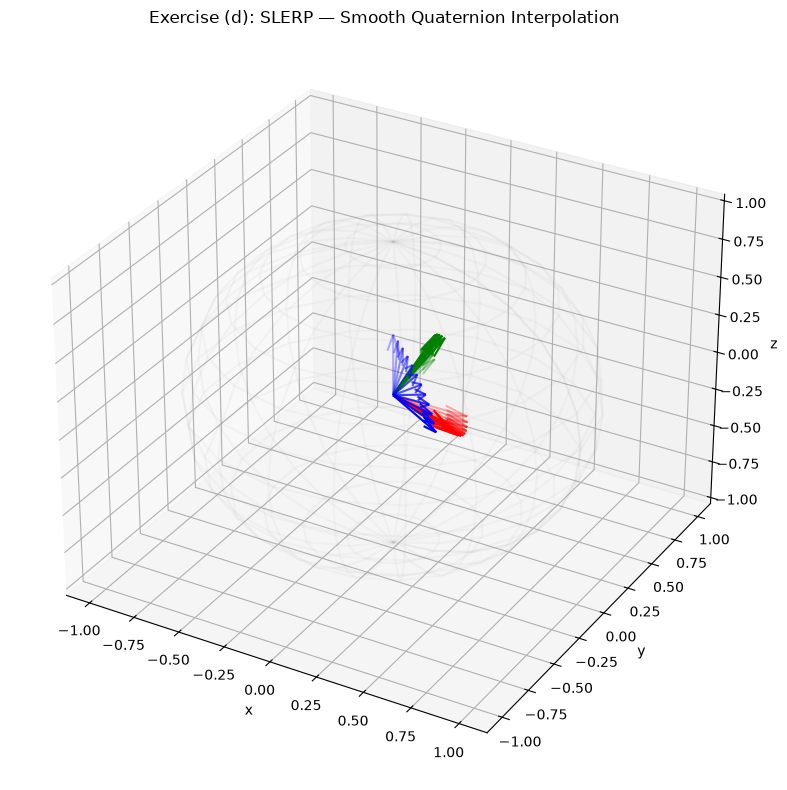

In [16]:
q_start = tf.matrix_to_quaternion(np.eye(3))
q_end = tf.matrix_to_quaternion(
    tf.rotation_matrix_from_euler(np.deg2rad(90), np.deg2rad(45), np.deg2rad(60))
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Unit sphere
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:15j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  alpha=0.05, color='gray')

steps = 12
colors_t = plt.cm.viridis(np.linspace(0, 1, steps))

for idx, t in enumerate(np.linspace(0, 1, steps)):
    q_t = tf.slerp(q_start, q_end, t)
    R_t = tf.quaternion_to_matrix(q_t)
    length = 0.4
    for j, c in enumerate(['r', 'g', 'b']):
        alpha = 0.3 + 0.7 * t
        ax.quiver(0, 0, 0, R_t[0,j]*length, R_t[1,j]*length, R_t[2,j]*length,
                  color=c, alpha=alpha, linewidth=1.5)

ax.set_title('Exercise (d): SLERP — Smooth Quaternion Interpolation')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

### Exercise (e): Verify $\exp(\log(R)) = R$ for Random Rotations

In [17]:
print("Verifying exp(log(R)) = R using the library functions:")
for i in range(10):
    omega = np.random.randn(3) * np.pi * np.random.rand()
    R = tf.so3_exp(omega)
    omega_rec = tf.so3_log(R)
    R_rec = tf.so3_exp(omega_rec)
    err = np.linalg.norm(R - R_rec)
    is_valid = tf.is_rotation_matrix(R_rec)
    print(f"  Trial {i+1:2d}: ‖R - exp(log(R))‖ = {err:.2e}  SO(3)? {is_valid}")

Verifying exp(log(R)) = R using the library functions:
  Trial  1: ‖R - exp(log(R))‖ = 3.19e-16  SO(3)? True
  Trial  2: ‖R - exp(log(R))‖ = 7.73e-16  SO(3)? True
  Trial  3: ‖R - exp(log(R))‖ = 5.05e-17  SO(3)? True
  Trial  4: ‖R - exp(log(R))‖ = 1.90e-15  SO(3)? True
  Trial  5: ‖R - exp(log(R))‖ = 5.15e-16  SO(3)? True
  Trial  6: ‖R - exp(log(R))‖ = 0.00e+00  SO(3)? True
  Trial  7: ‖R - exp(log(R))‖ = 2.12e-15  SO(3)? True
  Trial  8: ‖R - exp(log(R))‖ = 0.00e+00  SO(3)? True
  Trial  9: ‖R - exp(log(R))‖ = 2.91e-14  SO(3)? True
  Trial 10: ‖R - exp(log(R))‖ = 3.55e-16  SO(3)? True


### Exercise (f): Geodesic Angle Between Rotations

Compute $\Delta\theta = \arccos\!\left(\frac{\text{tr}(R_1^\top R_2) - 1}{2}\right)$.

In [18]:
def angle_between_rotations(R1, R2):
    """Geodesic angle (in radians) between two rotation matrices."""
    cos_a = np.clip((np.trace(R1.T @ R2) - 1) / 2, -1, 1)
    return np.arccos(cos_a)

R1 = rodrigues(np.array([0, 0, 1]), np.deg2rad(30))
R2 = rodrigues(np.array([0, 0, 1]), np.deg2rad(75))
R3 = rodrigues(np.array([1, 0, 0]), np.deg2rad(90))

print("Geodesic angles between rotations:")
print(f"  R(z,30°) vs R(z,75°): {np.rad2deg(angle_between_rotations(R1, R2)):.1f}°")
print(f"  R(z,30°) vs R(x,90°): {np.rad2deg(angle_between_rotations(R1, R3)):.1f}°")
print(f"  R(z,75°) vs R(x,90°): {np.rad2deg(angle_between_rotations(R2, R3)):.1f}°")
print(f"  R1 vs R1 (self):      {np.rad2deg(angle_between_rotations(R1, R1)):.1f}°")

# Cross-check with library
a_lib = tf.angle_between_rotations(R1, R2)
print(f"\n  Library check: {np.rad2deg(a_lib):.1f}° (should match first result)")

Geodesic angles between rotations:
  R(z,30°) vs R(z,75°): 45.0°
  R(z,30°) vs R(x,90°): 93.8°
  R(z,75°) vs R(x,90°): 111.8°
  R1 vs R1 (self):      0.0°

  Library check: 45.0° (should match first result)


## Summary

### Key Equations

| Concept | Formula |
|---------|---------|
| Rodrigues | $R = I + \sin\theta\,[\hat{\omega}]_\times + (1-\cos\theta)\,[\hat{\omega}]_\times^2$ |
| Quaternion → Matrix | $R = I + 2w[\mathbf{v}]_\times + 2[\mathbf{v}]_\times^2$ |
| SE(3) composition | $T_1 T_2 = \begin{bmatrix} R_1 R_2 & R_1 t_2 + t_1 \\ 0 & 1 \end{bmatrix}$ |
| SE(3) inverse | $T^{-1} = \begin{bmatrix} R^\top & -R^\top t \\ 0 & 1 \end{bmatrix}$ |
| SO(3) exp map | $\exp([\omega]_\times) = I + \frac{\sin\theta}{\theta}[\omega]_\times + \frac{1-\cos\theta}{\theta^2}[\omega]_\times^2$ |
| SO(3) log map | $\log(R) = \frac{\theta}{2\sin\theta}(R - R^\top)$ |
| Adjoint of SE(3) | $\text{Ad}_T = \begin{bmatrix} R & [t]_\times R \\ 0 & R \end{bmatrix}$ |
| SE(3) left Jacobian | $\mathcal{J}_l = \begin{bmatrix} J_l(\phi) & Q \\ 0 & J_l(\phi) \end{bmatrix}$, $\;t = J_l(\phi)\,\rho$ |
| Camera conventions | OpenCV ($Z$ fwd), OpenGL ($Z$ back), ROS ($X$ fwd) |

### Key Takeaways

- Rotation matrices have 9 parameters but only 3 DoF → Lie algebra parameterises them with 3 numbers
- Quaternions avoid gimbal lock and support efficient interpolation (SLERP)
- SO(3) and SE(3) Lie groups are the mathematical backbone of pose optimisation in VO, SLAM, and BA
- The exponential/logarithm maps convert between the tangent space (where we optimise) and the group (where poses live)
- The SE(3) left Jacobian has block structure with $J_l(\phi)$ on the diagonal and the Q matrix coupling rotation and translation
- The adjoint $\text{Ad}_T$ transforms twists between frames; its block form follows from the conjugation $T\exp(\xi^\wedge)T^{-1}$
- Always verify camera coordinate conventions (OpenCV vs OpenGL vs ROS) and pose direction ($T_{cw}$ vs $T_{wc}$) when integrating systems

### What's Next

These transforms are used in every subsequent notebook: visual odometry (NB07), bundle adjustment (NB10), SLAM (NB14), and EKF sensor fusion (NB13).